<a href="https://colab.research.google.com/github/kamat-v/qc-course-materials/blob/main/notebooks/week08_graph_coloring_grover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph Vertex 3-Coloring via Grover's Algorithm

We use Grover's algorithm to find proper vertex 3-colorings of two families of graphs: odd cycles $C_{2k+1}$ and the Petersen graph. Each vertex is assigned one of three colors, encoded as two-bit strings $\{00, 01, 10\}$, and the search problem is modeled as a *satisfiability* instance that is converted into a phase oracle. All simulations are run using Qiskit's statevector
simulator.

In [18]:
# Install dependencies
!pip install qiskit qiskit-aer matplotlib pylatexenc --quiet

In [19]:
# Imports
import numpy as np
import math
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit_aer import AerSimulator
from qiskit_aer import StatevectorSimulator
from qiskit.circuit.library import PhaseOracleGate

##Boolean encodings of $3$-colorings of $C_{2k+1}$ for $k\geq 2$ (odd length cycles) and the Petersen graph $\text{K}(5,2)$.

We encode proper vertex $3$-colorings of both the odd cycle $C_{2k+1}$ and the famous Petersen graph as Boolean formulas. Each vertex gets two Boolean variables to represent its color. In both instances, we fix vertex $0$ to get color $00$, and vertex $1$ to get color $01$ to break color-permutation symmetry, and make the runs simulator-friendly.

In [28]:
def var(i,m):
    width = len(str(2*(m) - 1))  # enough digits for largest variable index
    return f'x{i:0{width}d}'

#Encoding 3-colorings for the odd cycle

def get_oddcn_coloring_expression(k):
    m = 2*k+1
    edges = [(i, (i+1) % m) for i in range(m)]
    constraints = []

    # 0. Fix the color of vertex 0 to color 00, vertex 1 to color 01
    constraints.append(f'~{var(0,m)} & ~{var(1,m)}')
    constraints.append(f'~{var(2,m)} & {var(3,m)}')

    # 1. Valid Color Constraint: Each vertex must be 00, 01, or 10
    for i in range(2,m):
        u0, u1 = var(2*i, m), var(2*i+1, m)
        constraints.append(f'~({u0} & {u1})')

    # 2. Edge Constraint: (u0 != v0) OR (u1 != v1)
    for u, v in edges:
        u0, u1 = var(2*u, m), var(2*u+1, m)
        v0, v1 = var(2*v, m), var(2*v+1, m)
        # Standard inequality check
        constraints.append(f'({u0} ^ {v0} | {u1} ^ {v1})')

    return ' & '.join(constraints)


#Encoding 3-colorings for the Petersen graph
def get_petersen_coloring_expression():
    m = 10
    edges=[]
    outer_cycle=[(i,(i+1)%5) for i in range(5)]
    edges.extend(outer_cycle)
    inner_cycle=[(i+5, (i+7)%5+5) for i in range(5)]
    edges.extend(inner_cycle)
    cross_edges=[(i,i+5) for i in range(5)]
    edges.extend(cross_edges)
    constraints = []

    # 0. Fix the color of vertex 0 to color 00 and vertex 1 to 01
    constraints.append(f'~{var(0,m)} & ~{var(1,m)}')
    constraints.append(f'~{var(2,m)} & {var(3,m)}')

    # 1. Valid Color Constraint: Each vertex must be 00, 01, or 10
    for i in range(2,m):
        u0, u1 = var(2*i, m), var(2*i+1, m)
        constraints.append(f'~({u0} & {u1})')

    # 2. Edge Constraint: (u0 != v0) OR (u1 != v1)
    for u, v in edges:
        u0, u1 = var(2*u, m), var(2*u+1, m)
        v0, v1 = var(2*v, m), var(2*v+1, m)
        # Standard inequality check
        constraints.append(f'({u0} ^ {v0} | {u1} ^ {v1})')

    return ' & '.join(constraints)

### The Grover Diffusion Operator $D = 2|s\rangle\langle s| - I$
$D$ reflects amplitudes about the mean. Its circuit decomposition is:

$$D = H^{\otimes n} (2|0\rangle\langle 0| - I) H^{\otimes n},$$

where $(2|0\rangle\langle 0| - I)$ flips the phase of everything *except* |00...0⟩, and is implemented as: $$X^{\otimes n} \to \text{MCZ} \to X^{\otimes n}.$$

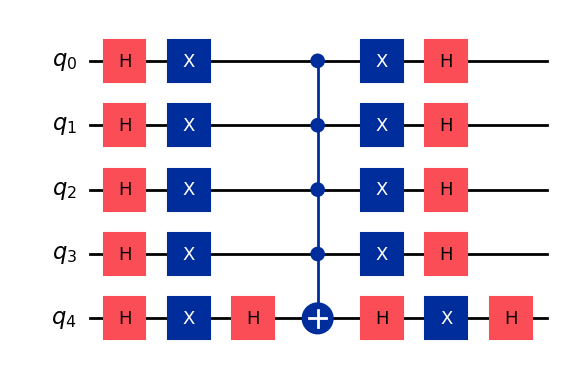

In [29]:
def diffusion_operator(n):
    """
    Returns a QuantumCircuit implementing D = 2|s><s| - I.
    """
    qc = QuantumCircuit(n, name='D')

    # H to the nth tensor power
    qc.h(range(n))
    # 2|0><0| - I: flip phase of all states except all zeroes
    qc.x(range(n))
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    qc.x(range(n))

    # H to the nth tensor power
    qc.h(range(n))

    return qc

diffuser = diffusion_operator(5)
diffuser.draw('mpl', style='iqp')

With the diffusion operator defined, the phase oracle $Z_f$ will be constructed using our $3$-coloring encodings in conjunction with **Qiskit's** *PhaseGateOracle* function. As per the definition, this phase oracle assigns a phase of $-1$ only to those bitstrings that correspond to proper $3$-colorings of the corresponding graph -- $C_{2k+1}$ or $\text{K}(5,2)$.

We now assemble a circuit for the full Grover iteration. Starting from a uniform superposition over all $2^n$ bitstrings, we apply $k$ iterations, where $k\approx \frac{\pi}{4}\sqrt{\frac{N}{M}}$, with $N=2^n$ and $M$ being the number of solutions.   

In [22]:
def grover_circuit(n, oracle_gate, iterations):
    """
    Builds the full Grover circuit for the given number of iterations.
    oracle_gate: a Gate (e.g., PhaseOracleGate(expr)) acting on n qubits
    """
    qc = QuantumCircuit(n, n)

    # Step 0: uniform superposition
    qc.h(range(n))
    qc.barrier()

    diffuser = diffusion_operator(n)

    for _ in range(iterations):
        # Oracle
        qc.append(oracle_gate, range(n))

        # Diffusion (convert circuit to gate)
        qc.append(diffuser.to_gate(), range(n))
        qc.barrier()

    qc.measure(range(n), range(n))
    return qc

##Finding $3$-cycles in $C_{2k+1}$

For cycle $C_{2k+1}$, the total number of proper vertex $3$-colorings is $2^{2k+1}-2$. As we've fixed the colors of vertices $0$ and $1$ to be $00$ and $01$ respectively, we divide by $6$ to obtain the total number of solutions $M$.

In [23]:
k=4 #cycle on 2(k)+1 vertices
m_cycle=2*k+1
expr = get_oddcn_coloring_expression(k)
oracle_gate_cycle = PhaseOracleGate(expr)
n = oracle_gate_cycle.num_qubits
N = 2**n
M_cycle = int((2**(2*k+1)-2)/6) #fixing vertex 0 to color 00, vertex 1 to color 01
iterations = int((np.pi/4) * np.sqrt(N/M_cycle))
print(m_cycle,n,N,M_cycle,iterations)
qc_cycle = grover_circuit(n, oracle_gate_cycle, iterations)

9 18 262144 85 43


In [24]:
print(oracle_gate_cycle.definition.depth())

72


##Finding $3$-cycles in $\text{K}(5,2)$

For the Petersen graph $\text{K}(5,2)$, the total number of proper vertex $3$-colorings is $120$. As before, we've fixed the colors of vertices $0$ and $1$ to be $00$ and $01$ respectively, so we divide by $6$ to obtain the total number of solutions $M=20$.

In [36]:
expr = get_petersen_coloring_expression()
oracle_gate_petersen = PhaseOracleGate(expr)
m_petersen=10
n = oracle_gate_petersen.num_qubits
N = 2**n
M_petersen = 20 #fixing v0 to  color 00 and v1 to 01
iterations = int((np.pi/4) * np.sqrt(N/M_petersen))
print(m_petersen,n,N,M_petersen,iterations)
qc_petersen = grover_circuit(n, oracle_gate_petersen, iterations)

10 20 1048576 20 179


In [37]:
print(oracle_gate_petersen.definition.depth())

31


In [38]:
# Simulate and gather results
simulator = AerSimulator()
shots = 2048

tqc = transpile(qc_petersen, simulator) #change depending on the graph
result = simulator.run(tqc, shots=shots).result()
counts = result.get_counts()

The code below makes the measurement results more human-readable. More precisely,
the measured bitstrings are separated into pairs, each pair corresponding
to the color assigned to a vertex. From $2048$ shots, we display the top
$20$ measurement outcomes, each of which should be a valid proper
$3$-coloring of the graph — a sign that Grover search is amplifying the
correct solutions.

In [39]:
def decode_coloring(bitstring):
    """
    bitstring: e.g. '0101...'(Qiskit returns classical string with highest cbit on left)
    Assumes you measured qc.measure(range(n), range(n)).
    We reverse to align x0 as the leftmost index in list below.
    """
    b = bitstring[::-1]  # now b[i] corresponds to x_i
    colors = []
    for i in range(m_petersen): #change this depending on the graph you are working with
        c = b[2*i] + b[2*i+1]   # x_{2i} x_{2i+1}
        colors.append(c)
    return tuple(colors)  # ('00','01','10','00','01')

def summarize_counts_as_colorings(counts, top_k=20):
    agg = {}
    for s, c in counts.items():
        coloring = decode_coloring(s)
        agg[coloring] = agg.get(coloring, 0) + c
    # sort by frequency
    items = sorted(agg.items(), key=lambda kv: kv[1], reverse=True)[:top_k]
    for coloring, c in items:
        print(c, coloring)

summarize_counts_as_colorings(counts)


118 ('00', '01', '00', '01', '10', '01', '10', '10', '00', '00')
118 ('00', '01', '10', '00', '10', '01', '00', '00', '10', '01')
115 ('00', '01', '10', '00', '10', '10', '10', '01', '01', '00')
113 ('00', '01', '10', '00', '01', '10', '00', '01', '01', '10')
112 ('00', '01', '10', '00', '01', '01', '00', '00', '10', '10')
110 ('00', '01', '00', '10', '01', '10', '00', '01', '01', '10')
107 ('00', '01', '00', '10', '01', '01', '10', '10', '00', '00')
104 ('00', '01', '00', '10', '01', '10', '10', '01', '00', '00')
102 ('00', '01', '00', '01', '10', '01', '00', '10', '10', '01')
102 ('00', '01', '10', '00', '01', '10', '10', '01', '01', '00')
98 ('00', '01', '10', '00', '01', '10', '00', '00', '01', '10')
98 ('00', '01', '10', '01', '10', '01', '00', '00', '10', '01')
97 ('00', '01', '00', '01', '10', '10', '10', '01', '00', '00')
96 ('00', '01', '10', '01', '10', '10', '10', '00', '00', '01')
96 ('00', '01', '10', '00', '10', '10', '10', '00', '01', '01')
96 ('00', '01', '00', '01', '1